# WikiNews NLP: entities, summaries and similarity

A walk-through of the results. The computation happens in the pipeline; this notebook reads the
tables `make all` produced, so its numbers match `reports/findings.md`.

In [1]:
import sys
from pathlib import Path

# Package root on the path.
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import pandas as pd
from IPython.display import Image, display

from src import config

pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 160)


def load(path: Path) -> pd.DataFrame:
    """Read a pipeline output table."""
    if not path.exists():
        raise FileNotFoundError(f"{path.name} missing — run `make all` from the project root.")
    return pd.read_parquet(path)

## 1. Corpus and scope

Four categories in four languages, capped at 800 articles per language and sampled with a fixed
seed, which keeps the corpus's own category and year mix.

In [2]:
corpus = load(config.CORPUS_FILE)
print(f"{len(corpus):,} articles, {corpus['year'].min()}-{corpus['year'].max()}")
pd.crosstab(corpus["lang"], corpus["primary_category"], margins=True, margins_name="total")

3,200 articles, 2004-2022


primary_category,Crime and law,Disasters and accidents,Politics and conflicts,Science and technology,total
lang,,,,,
de,100,194,422,84,800
en,106,165,431,98,800
es,117,173,424,86,800
fr,84,146,469,101,800
total,407,678,1746,369,3200


### 1.1 Date coverage after backfilling

The raw corpus dates only English pages in ISO format; translations keep a local-format string.
Articles sharing a `pageid` describe the same event, so the English date backfills onto its
translations.

In [3]:
coverage = corpus.groupby("lang")["date"].apply(lambda s: s.notna().mean()).round(3)
coverage.to_frame("share with a usable ISO date")

,share with a usable ISO date
lang,
de,0.996
en,0.998
es,0.995
fr,0.996


## 2. Pre-processing: tokens, POS tags and lemmas (requirement 1)

Every article sentence-split, tokenized, POS-tagged, dependency-parsed and lemmatized by its own
language's spaCy pipeline.

Read the proper-noun row: comparable articles about the same events should not differ much in name
density, so a gap there is an early signal that the non-English taggers find fewer names.

In [4]:
tokens = load(config.TOKENS_FILE)
print(f"{len(tokens):,} tokens")
profile = (pd.crosstab(tokens["pos"], tokens["lang"], normalize="columns") * 100).round(1)
profile.loc[["PROPN", "NOUN", "VERB", "ADJ", "DET"]]

1,074,437 tokens


lang,de,en,es,fr
pos,,,,
PROPN,7.2,11.6,10.4,6.7
NOUN,21.1,18.2,18.6,21.0
VERB,8.0,10.5,8.3,8.7
ADJ,5.7,5.8,6.0,6.0
DET,13.5,9.4,13.1,13.4


In [5]:
# One article's tokens.
sample = tokens[tokens["pageid"] == tokens["pageid"].iloc[0]].head(12)
sample[["sent_id", "token", "lemma", "pos", "tag", "dep", "is_stop"]]

,sent_id,token,lemma,pos,tag,dep,is_stop
0,0,MADRID,madrid,NOUN,NN,ROOT,False
1,0,—,—,PUNCT,:,punct,False
2,0,The,the,DET,DT,det,True
3,0,Basque,basque,ADJ,JJ,amod,False
4,0,separatist,separatist,NOUN,NN,compound,False
5,0,group,group,NOUN,NN,nsubjpass,False
6,0,ETA,ETA,PROPN,NNP,appos,False
7,0,was,be,AUX,VBD,auxpass,True
8,0,blamed,blame,VERB,VBN,acl,False
9,0,for,for,ADP,IN,prep,True


## 3. Named entity recognition: mentions and metadata (requirement 2)

One row per mention, each carrying its article: identifier, title, language, category, date,
character offsets and the containing sentence.

The pipelines do not share a label set — English uses OntoNotes (18 labels), the others WikiNER
(4) — so everything is mapped onto a coarse scheme before any comparison.

In [6]:
entities = load(config.ENTITIES_FILE)
print(f"{len(entities):,} mentions, {entities['entity_key'].nunique():,} distinct entities")
entities[["pageid", "lang", "category", "entity", "label", "label_raw", "year"]].head(8)

75,855 mentions, 28,886 distinct entities


,pageid,lang,category,entity,label,label_raw,year
0,1356,en,Politics and conflicts,Basque,OTHER,NORP,2004.0
1,1356,en,Politics and conflicts,ETA,ORGANISATION,ORG,2004.0
2,1356,en,Politics and conflicts,Spanish,OTHER,NORP,2004.0
3,1356,en,Politics and conflicts,Madrid,LOCATION,GPE,2004.0
4,1356,en,Politics and conflicts,Basque,OTHER,NORP,2004.0
5,1356,en,Politics and conflicts,Gara,PERSON,PERSON,2004.0
6,1356,en,Politics and conflicts,ETA,ORGANISATION,ORG,2004.0
7,1356,en,Politics and conflicts,Spanish,OTHER,NORP,2004.0


In [7]:
(pd.crosstab(entities["label"], entities["lang"], normalize="columns") * 100).round(1)

lang,de,en,es,fr
label,,,,
LOCATION,45.3,31.5,35.4,40.0
ORGANISATION,16.5,29.0,14.1,19.2
OTHER,19.5,15.1,24.1,13.6
PERSON,18.8,24.4,26.4,27.2


### 3.1 Aggregated view: leading entities per category

Ranked by the number of articles mentioning an entity, not by raw mentions: a name repeated eleven
times in one story is still one story.

In [8]:
aggregated = load(config.ENTITY_AGGREGATE_FILE)
top = (aggregated[aggregated["lang"] == "en"]
       .sort_values("articles", ascending=False)
       .groupby("category", observed=True).head(5))
top[["category", "surface", "label", "articles", "mentions"]]

,category,surface,label,articles,mentions
13316,Politics and conflicts,U.S,LOCATION,168,446
13317,Politics and conflicts,UN,ORGANISATION,51,105
13318,Politics and conflicts,UK,LOCATION,43,80
13319,Politics and conflicts,Iraq,LOCATION,42,127
11361,Disasters and accidents,UTC,ORGANISATION,39,53
13320,Politics and conflicts,EU,ORGANISATION,36,107
11362,Disasters and accidents,U.S,LOCATION,31,43
10105,Crime and law,U.S,LOCATION,28,65
17787,Science and technology,U.S,LOCATION,23,31
11363,Disasters and accidents,USGS,ORGANISATION,22,58


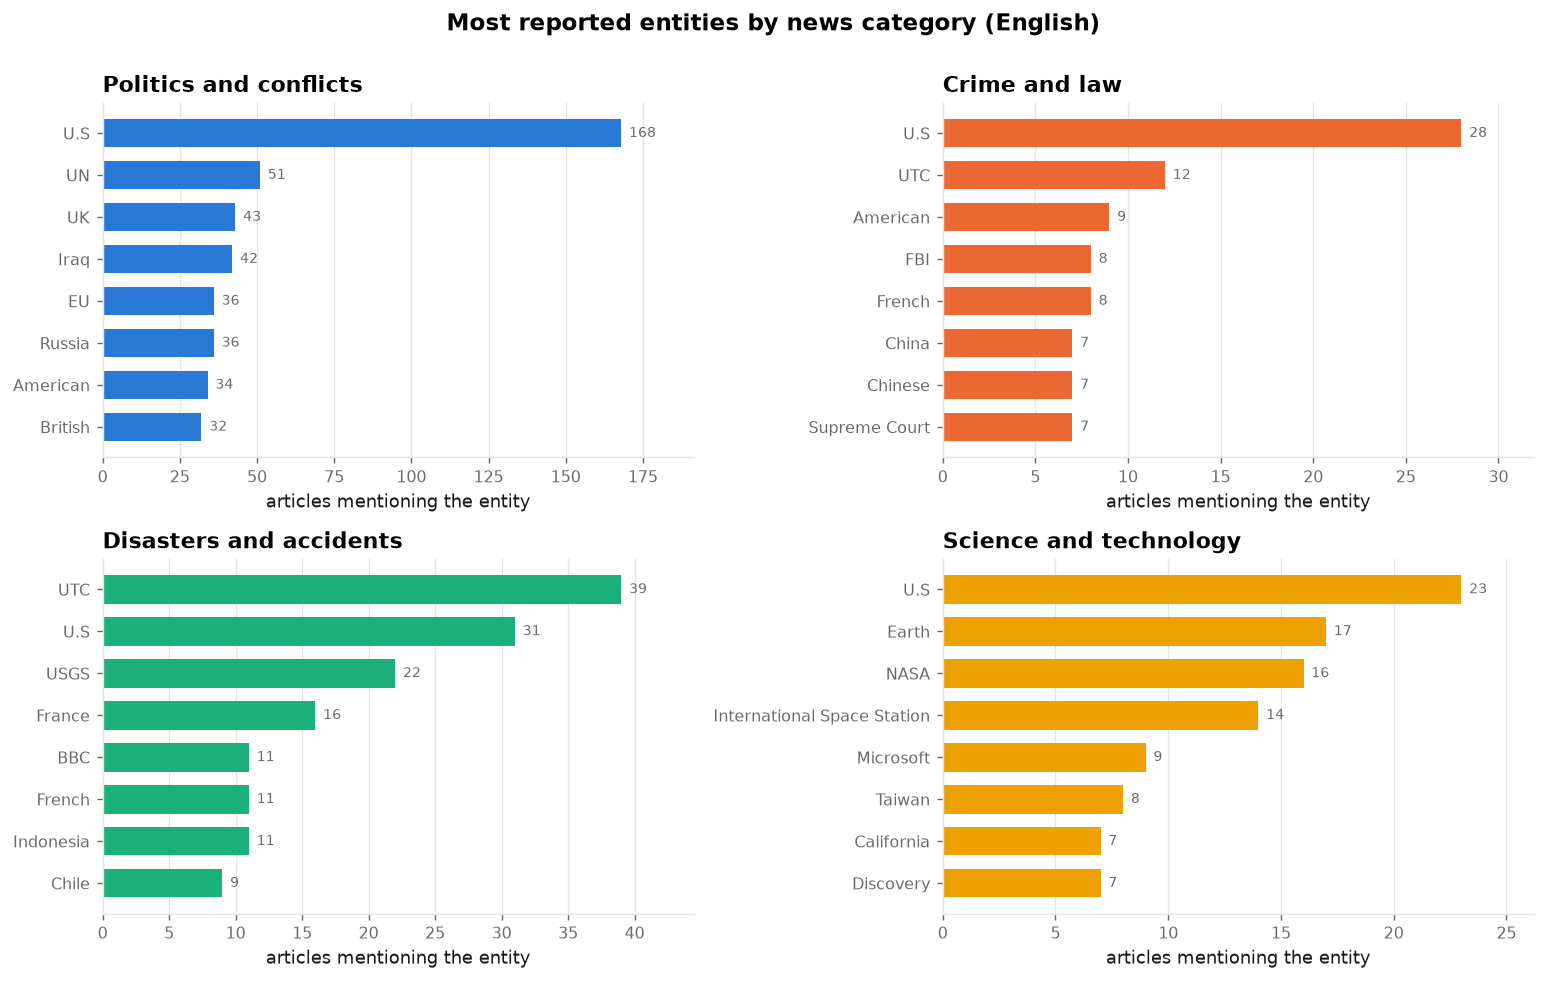

In [9]:
display(Image(filename=str(config.FIGURES_DIR / "entities_by_category.png")))

### 3.2 Dynamics over time: articles per year

Articles per year for the most reported entities. Entities tied to a particular political moment
appear and disappear with it; state-level entities persist across the whole period.

Article volume declines after 2011 because WikiNews published less, so the later years should not
be read as a trend.

In [10]:
timeline = load(config.ENTITY_TIMELINE_FILE)
timeline

entity_key,American,China,France,French,UK,UN,U.S,UTC
year,,,,,,,,
2004,0,0,0,0,0,0,2,0
2005,8,7,10,10,10,14,39,9
2006,8,8,9,8,4,8,36,9
2007,8,4,5,6,15,8,34,4
2008,9,12,5,4,5,11,35,8
2009,7,3,5,4,3,4,13,6
2010,4,8,5,4,8,6,26,17
2011,0,3,5,4,6,3,14,9
2012,2,1,2,1,2,3,11,3


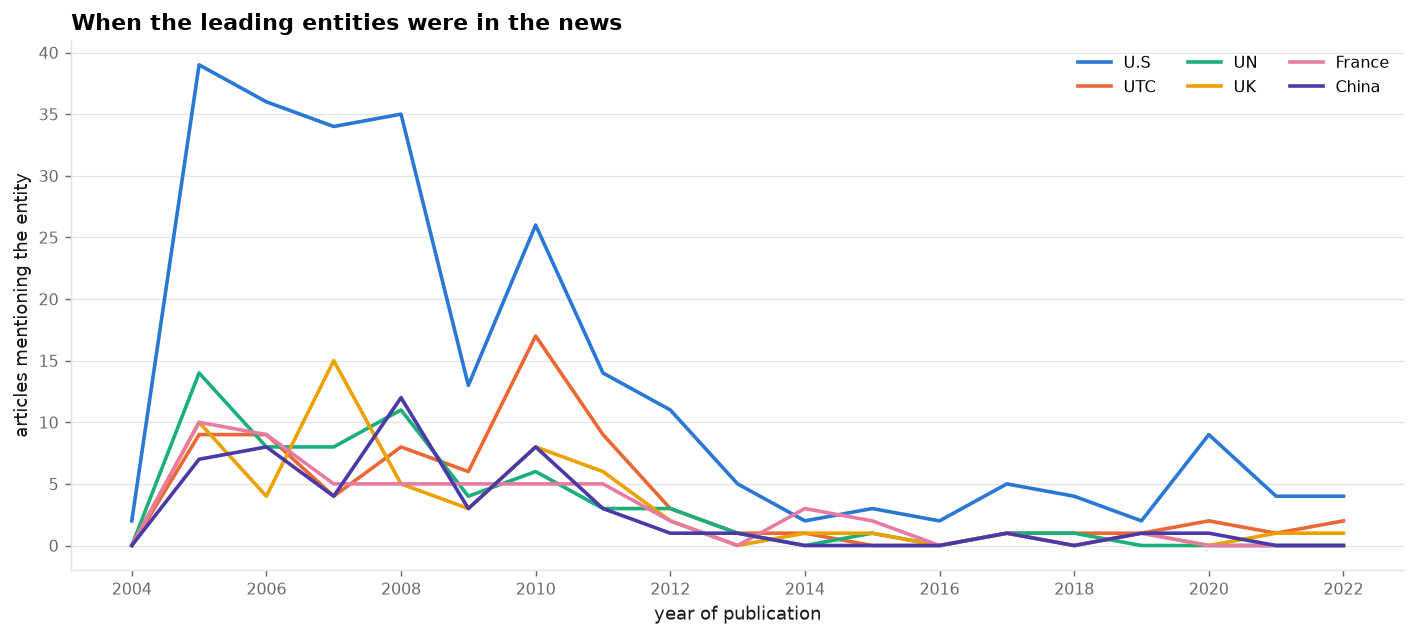

In [11]:
display(Image(filename=str(config.FIGURES_DIR / "entity_timeline.png")))

### 3.3 Semantic groups: clustered entity embeddings

The most reported English entities, embedded with a multilingual encoder and clustered with
K-means. Entity names are very short strings, so the clusters overlap at the edges — the grouping
is indicative, not a hard partition.

In [12]:
clusters = load(config.ENTITY_CLUSTERS_FILE)
(clusters.sort_values("articles", ascending=False)
         .groupby("cluster")["surface"]
         .apply(lambda names: ", ".join(names.head(8)))
         .to_frame("members"))

,members
cluster,
0,"U.S, UTC, UN, New York, Reuters, Wikinews, Associated Press, Calif..."
1,"France, French, Russia, EU, Russian, German, European, Europe"
2,"Iraq, Afghanistan, Iraqi, Israel, Iran, Israeli, Baghdad, Iranian"
3,"American, George W. Bush, Bush, Senate, Washington, Democratic, Ba..."
4,"UK, British, BBC, Australia, Pakistan, London, India, Australian"
5,"China, Chinese, Japan, Japanese, Indonesia, Taiwan, South Korea, B..."


### 3.4 Geographic focus: places per category

Where each category concentrates, read back out of the LOCATION entities the pipeline already
found. No gazetteer is used, so this ranks places rather than countries specifically.

In [13]:
places = load(config.GEOGRAPHY_FILE)
places[["category", "place", "articles", "first_year", "last_year"]]

,category,place,articles,first_year,last_year
0,Politics and conflicts,U.S,167,2004.0,2022.0
1,Politics and conflicts,UK,43,2005.0,2022.0
2,Politics and conflicts,Iraq,42,2005.0,2020.0
3,Politics and conflicts,Russia,36,2005.0,2022.0
4,Politics and conflicts,Afghanistan,31,2005.0,2021.0
5,Politics and conflicts,China,31,2005.0,2020.0
6,Disasters and accidents,U.S,30,2005.0,2020.0
7,Crime and law,U.S,28,2005.0,2022.0
8,Science and technology,U.S,22,2005.0,2022.0
9,Science and technology,Earth,17,2005.0,2022.0


## 4. Wrongly predicted entities across languages (requirement 3)

No gold annotation ships with this corpus, so accuracy cannot be measured directly. Three checks
stand in for it:

1. **Missed entities** — a person named in the English article, appearing verbatim in the
   translated article's text, that the other pipeline did not tag. Places are excluded, because
   they get translated (London / Londres).
2. **Label disagreements** — the same name labelled differently by two pipelines.
3. **Surface issues** — spans readable as wrong from their own shape.

In [14]:
recall = load(config.NER_RECALL_FILE)
recall

,lang,checked,found,recall_proxy
0,de,304,277,0.911
1,es,371,361,0.973
2,fr,355,345,0.972


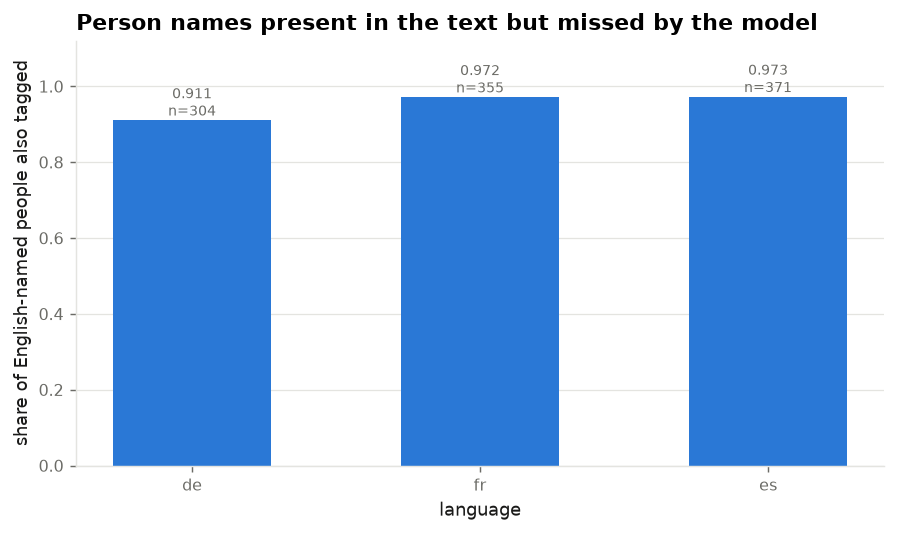

In [15]:
display(Image(filename=str(config.FIGURES_DIR / "ner_recall_by_language.png")))

In [16]:
# Flagged spans per language.
flagged = load(config.NER_ERRORS_FILE)
flagged.groupby(["lang", "error_type"]).size().unstack(fill_value=0)

error_type,determiner_included,lowercase_span,stray_punctuation
lang,,,
de,5,43,0
en,65,1,2
es,58,14,1
fr,5,6,0


In [17]:
flagged[flagged["error_type"] == "lowercase_span"][["lang", "entity", "label", "sentence"]].head(10)

,lang,entity,label,sentence
3,fr,pots-de-vin,ORGANISATION,Il y a eu plusieurs cas de corruption très médiatisés ses dernière...
5,de,israelischen,OTHER,"Hassan Fadlallah, der Hisbollah-Abgeordnete im libanesischen Parla..."
6,es,carbón,PERSON,Una explosión en una mina de carbón ha causado la muerte de al men...
14,es,pakistaníes,OTHER,"De acuerdo con el Mayor General Arshad, cinco tropas pakistaníes h..."
19,de,französische,OTHER,Der französische Verkehrsminister Dominique Bussereau erklärte im ...
20,de,französisches,OTHER,"Wie Mitarbeiter der Bücherei berichten, zählen die Harry-Potter-Ro..."
24,fr,pots-de-vin,ORGANISATION,"Quelques temps après son départ du gouvernement, il avait fait l'o..."
27,de,schlimmstmögliche,OTHER,"Es war das schlimmstmögliche Szenario, das eintrat"
29,de,demokratische,OTHER,"Boston (Vereinigte Staaten), 22.05.2008 – Wie das Massachusetts Ge..."
41,es,forton,LOCATION,"La minstro pri mensosano, bonfarto, kaj kimra lingvo Eluned Morgan..."


## 5. Summarization: extractive and abstractive (requirement 4)

Ten articles per category per language, summarized two ways:

- **Extractive (TextRank)** — sentences ranked by PageRank over a TF-IDF similarity graph and
  returned in document order. Offline and deterministic.
- **Abstractive (LLM)** — fixed prompt, low temperature, in the article's own language, cached to
  disk.

Section 6 compares them.

In [18]:
summaries = load(config.SUMMARIES_FILE)
n_articles = len(summaries.drop_duplicates(["lang", "pageid"]))
print(f"{n_articles} articles, {len(summaries)} summaries")
summaries.pivot_table(index="method", columns="lang", values="compression", aggfunc="median").round(3)

160 articles, 320 summaries


lang,de,en,es,fr
method,,,,
abstractive,0.296,0.243,0.258,0.288
extractive,0.302,0.320,0.377,0.426


In [19]:
# One article, both summaries.
english = summaries[summaries["lang"] == "en"]
pageid = english["pageid"].iloc[0]
for row in english[english["pageid"] == pageid].itertuples():
    print(f"--- {row.method} ---\n{row.summary}\n")

--- extractive ---
In addition to the sex charges, Berlusconi was found guilty of abusing his office when dealing with El Mahroug. Prosecutors alleged that El Mahroug was just one of many women Berlusconi had paid for sex with and that she formed part of "a prostitution system set up for the personal sexual satisfaction of the defendant". In May of this year, an Italian appeals court upheld a conviction for tax fraud which Berlusconi is in the process of appealing to the country's highest appellate court, the Court of Cassation.

--- abstractive ---
Silvio Berlusconi was convicted of having sex with an underage prostitute, sentenced to seven years and banned from public office. Prosecutors said she was Moroccan-born dancer Karima El Mahroug, aka Ruby Rubacuori, who denies sex but admits receiving thousands of euros. The court found he abused his office by pressuring Milan police to release her, and he is appealing a separate tax‑fraud conviction.



### 5.1 Grammar and style: readability and defect rates

Readability with each language's own Flesch weights, plus deterministic checks for the defects
summarizers produce. The two methods fail differently: extractive summaries inherit unresolved
pronouns and overlong sentences from the sentences they lift.

In [20]:
quality = load(config.GRAMMAR_FILE)
faults = ["truncated", "repeated_sentence", "opens_with_pronoun", "has_preamble", "overlong_sentence"]
(quality.groupby("method", observed=True)[faults].mean() * 100).round(1)

,truncated,repeated_sentence,opens_with_pronoun,has_preamble,overlong_sentence
method,,,,,
abstractive,0.0,0.6,0.0,0.0,0.0
extractive,6.9,0.6,1.9,0.0,40.0


In [21]:
quality.pivot_table(index="method", columns="lang", values="words_per_sentence", aggfunc="mean").round(1)

lang,de,en,es,fr
method,,,,
abstractive,16.8,19.2,19.7,20.0
extractive,19.9,25.7,32.9,30.3


## 6. Summary-to-source similarity (requirement 5)

Cosine between multilingual embeddings of the summary and the full source article. Long articles
are chunked at sentence boundaries and the chunk vectors averaged; without that the encoder's
input window would truncate each article and every score would compare a summary against the
opening paragraph.

**Lexical overlap** — the share of the summary's words that appear in the source — is reported
alongside it, and the pair is what makes the scores readable.

In [22]:
scored = load(config.SIMILARITY_FILE)
from src.analysis.similarity import distribution, drivers, threshold_check

distribution(scored, threshold=0.8)

,method,category,n,median,p10,max,pct_above_0.8
0,abstractive,Crime and law,40,0.864,0.707,0.972,77.5
1,abstractive,Disasters and accidents,40,0.840,0.749,0.955,65.0
2,abstractive,Politics and conflicts,40,0.843,0.759,0.971,77.5
3,abstractive,Science and technology,40,0.861,0.791,0.960,85.0
4,extractive,Crime and law,40,0.860,0.744,0.958,75.0
5,extractive,Disasters and accidents,40,0.814,0.654,0.944,52.5
6,extractive,Politics and conflicts,40,0.842,0.702,0.991,67.5
7,extractive,Science and technology,40,0.859,0.734,0.976,72.5


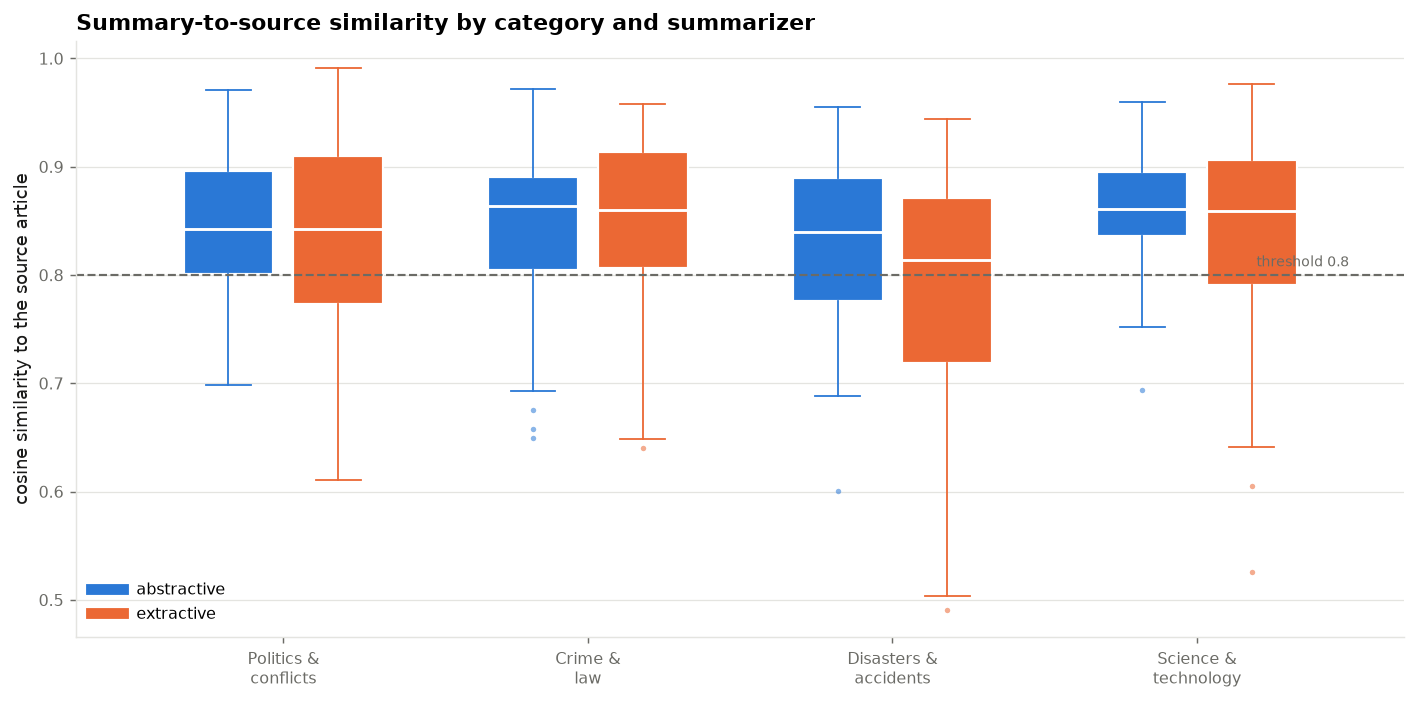

In [23]:
display(Image(filename=str(config.FIGURES_DIR / "similarity_distribution.png")))

### 6.1 Lexical reuse against semantic similarity

An extractive summary is made of the source's own sentences, so its lexical overlap sits near 1.0
and the encoder is being asked how similar a text is to a document containing it. A high
abstractive score carries more information, because the wording changed and the meaning still
matched.

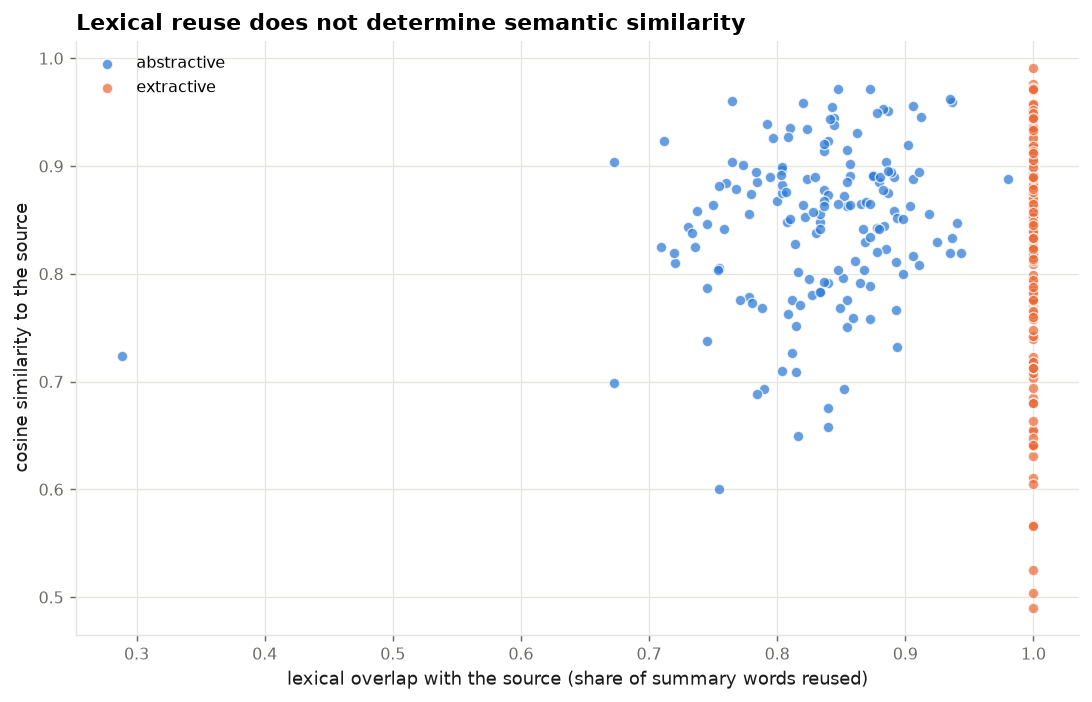

In [24]:
display(Image(filename=str(config.FIGURES_DIR / "similarity_vs_overlap.png")))

In [25]:
threshold_check(scored, 0.8).to_frame("% at or above 0.8")

,% at or above 0.8
method,
abstractive,76.2
extractive,66.9


In [26]:
# Correlated inside each method: pooled, the coefficient measures the gap
# between the methods rather than anything within one.
drivers(scored)

,compression,lexical_overlap,source_chars,summary_chars
abstractive,0.566,0.162,-0.569,-0.103
extractive,0.426,NaN,-0.238,0.176


### 6.2 Highest and lowest scoring summaries

The lowest scores share a shape: a long, multi-topic source compressed hard. When an article
covering several developments is reduced to three sentences, the summary keeps one of them while
the document embedding averages over all — a property of single-vector similarity rather than
evidence of a poor summary.

The highest scores go to short, single-topic articles where three sentences cover the whole piece.

In [27]:
from src.analysis.similarity import extremes

highest, lowest = extremes(scored, n=3)
columns = ["method", "lang", "category", "title", "similarity", "lexical_overlap", "compression"]
print("HIGHEST"); display(highest[columns])
print("LOWEST"); display(lowest[columns])

HIGHEST


,method,lang,category,title,similarity,lexical_overlap,compression
0,abstractive,de,Politics and conflicts,Gordon Brown ist neuer britischer Premierminister,0.9626,0.9348,0.650
1,abstractive,en,Politics and conflicts,Rick Santorum gains traction by winning Louisiana vote,0.9712,0.8478,0.578
2,abstractive,fr,Crime and law,Pakistan : au moins 56 personnes mortes dans une explosion,0.9717,0.8727,0.753
3,extractive,fr,Science and technology,Des scientifiques sud-coréens ont effectué le premier clonage de c...,0.9727,1.0000,0.952
4,extractive,es,Science and technology,Steve Fosset bate el récord de distancia de vuelo sin escalas,0.9762,1.0000,0.787
5,extractive,es,Politics and conflicts,Continuan los violentos combates en la Franja de Gaza,0.9912,1.0000,0.707


LOWEST


,method,lang,category,title,similarity,lexical_overlap,compression
0,extractive,en,Disasters and accidents,U.S. prepares for arrival of Hurricane Sandy,0.4904,1.0000,0.067
1,extractive,de,Disasters and accidents,Flugzeug stürzt vor der libanesischen Küste ins Meer,0.5040,1.0000,0.332
2,extractive,en,Science and technology,Stem cells used to cure paralysis in rats,0.5254,1.0000,0.490
3,abstractive,en,Disasters and accidents,U.S. prepares for arrival of Hurricane Sandy,0.6003,0.7544,0.126
4,abstractive,es,Crime and law,Tiroteo en ceremonia de compromiso kurda deja docenas de muertos,0.6497,0.8163,0.206
5,abstractive,de,Crime and law,Terroranschläge in Norwegen: Mindestens 90 Tote und zahlreiche Ver...,0.6581,0.8400,0.059


In [28]:
# The lowest-scoring summary in full.
worst = scored.sort_values("similarity").iloc[0]
print(f"{worst['title']}  ({worst['method']}, similarity {worst['similarity']:.3f})")
print(f"source {worst['source_chars']} chars -> summary {worst['summary_chars']} chars\n")
print(worst["summary"])

U.S. prepares for arrival of Hurricane Sandy  (extractive, similarity 0.490)
source 3408 chars -> summary 229 chars

Air France announced that it will cancel all flights to New York and Washington today. He also said the worst of the storm has not yet reached the city. The Washington metro is also to be closed tomorrow because of the hurricane.


## 7. Topic prediction: TF-IDF and logistic regression

TF-IDF and logistic regression, trained per language on articles carrying exactly one topic so the
target is unambiguous.

The baseline matters: one category holds more than half the articles, so accuracy alone would look
respectable while saying nothing.

In [29]:
import json

metrics = json.loads(config.TOPIC_METRICS_FILE.read_text(encoding="utf-8"))
pd.DataFrame(metrics).T

,n_train,n_test,accuracy,macro_f1,baseline_macro_f1
en,2021.0,674.0,0.920,0.900,0.174
es,579.0,194.0,0.897,0.867,0.173
fr,537.0,180.0,0.917,0.891,0.185
de,440.0,147.0,0.905,0.870,0.175


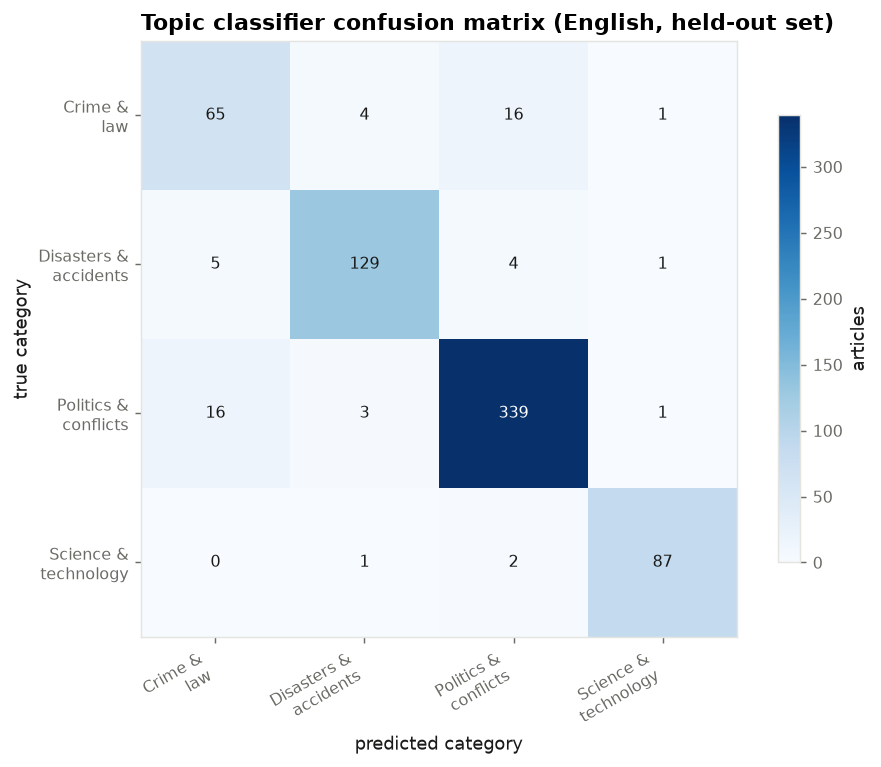

In [30]:
display(Image(filename=str(config.FIGURES_DIR / "topic_confusion.png")))

The one substantial error mode is Crime and law against Politics and conflicts, in both
directions — a genuine overlap in the source material, since the trial of a former head of state
is both.

## 8. Limitations

- The recall figures are a cross-lingual proxy, not measured recall against annotation. They
  support the ordering between languages, not a precise accuracy number.
- The `sm` spaCy pipelines hold model capacity constant across languages; larger ones shift the
  absolute figures.
- Entity aliasing is a short alias table, not entity linking.
- Similarity uses one vector per document, which penalises correct summaries of multi-topic
  articles.
- The corpus thins out after 2011, so later years rest on few articles.